# CodeBook Data Cleaning and Analysis

## Introduction

This project focuses on analysing and cleaning data from **CodeBook**, a social media platform designed for coders.

The dataset contains information about users, their connections, and the pages they have liked. The project uses Python to explore the structure of the data, identify data quality issues, and clean inconsistent or incomplete records.

The main objectives of this project are to:

- Load and explore the CodeBook user data
- Understand users, connections, and liked pages
- Identify missing, duplicate, and inconsistent data
- Clean and structure the dataset
- Apply basic Python data processing techniques without using libraries such as Pandas or NumPy

Through these tasks, the project demonstrates the importance of data cleaning and preparation before performing further analysis.

## Part 1: Data Preparation and Encoding

### Discussion

The class label **NObeyesdad** was removed because clustering is an unsupervised learning technique and does not use the target variable.

The dataset contains both numerical and categorical variables. Since clustering algorithms require numerical input, all categorical variables were converted into numerical values using OneHot Encoding.

OneHot Encoding creates separate binary columns for each category without introducing any order between them. This makes it suitable for distance like clustering methods such as KMeans and DBSCAN.

Different encoding methods may produce different clustering results. For example, Label Encoding assigns numbers to categories which may incorrectly do the order but OneHot Encoding avoids this problem and gives a better output for clustering.

In [17]:
import pandas as pd
import numpy as np

obesity = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")

X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

categorical_columns = X.select_dtypes(include="object").columns
# One-Hot Encoding
X_encoded = pd.get_dummies(X)

# encoded dataset
print("\nEncoded Dataset")
display(X_encoded.head())

print("\nDataTypes After Encoding")
print(X_encoded.dtypes.value_counts())


Encoded Dataset


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Female,Gender_Male,...,SCC_yes,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,True,False,...,False,False,False,False,True,False,False,False,True,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,True,False,...,True,False,False,True,False,False,False,False,True,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,False,True,...,False,False,True,False,False,False,False,False,True,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,False,True,...,False,False,True,False,False,False,False,False,False,True
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,False,True,...,False,False,False,True,False,False,False,False,True,False



DataTypes After Encoding
bool       23
float64     8
Name: count, dtype: int64


## Result

The target variable **NObeyesdad** was removed from the dataset before clustering.

All categorical variables were converted into numerical variables using One-Hot Encoding. After encoding, every feature became numerical making the dataset good for clustering algorithms.

The encoded dataset will be used for the remaining clustering tasks.

## Part 2: Determining the Optimal Number of Clusters

### Discussion

The Silhouette Coefficient was used to determine the optimal number of clusters (**k**). The Silhouette Score measures how well each data point belongs to assigned cluster compared to other. A higher score define better quality.

The Silhouette Score was calculated for different values of **k** and the value with the highest score was selected as the optimal number of clusters.

The obesity dataset contains **7 obesity classes**. After finding the optimal value of **k**, it can be compared with the actual number of classes. The two values may or may not be the same because clustering groups data based on similarity, while the class labels were assigned based on predefined obesity categories.

Silhouette Scores
k =2: 0.5681
k =3: 0.5021
k =4: 0.4738
k =5: 0.4293
k =6: 0.4550
k =7: 0.4401
k =8: 0.4348
k =9: 0.4120
k =10: 0.4184
Optimal Number of Clusters (k): 2


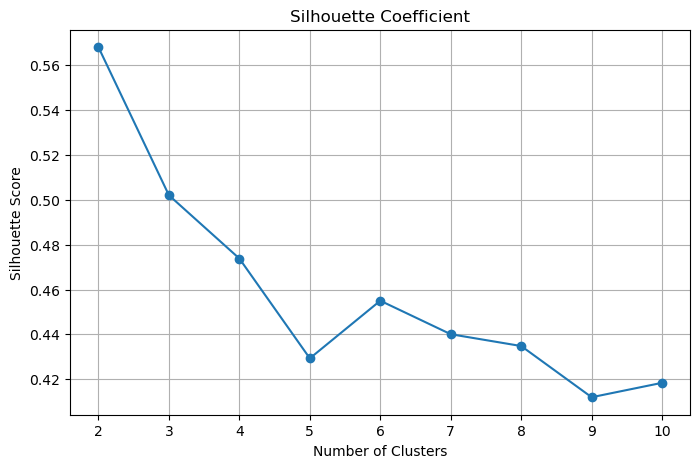

Actual Number of Obesity Classes: 7
Optimal k: 2


In [18]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores =[]
k_values =range(2, 11)

for k in k_values:
    kmeans =KMeans(n_clusters=k, random_state=42)
    cluster_labels= kmeans.fit_predict(X_encoded)

    score =silhouette_score(X_encoded, cluster_labels)
    silhouette_scores.append(score)

optimal_k= k_values[silhouette_scores.index(max(silhouette_scores))]

print("Silhouette Scores")
for k, score in zip(k_values, silhouette_scores):
    print(f"k ={k}: {score:.4f}")

print("Optimal Number of Clusters (k):", optimal_k)

plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Coefficient")
plt.grid(True)
plt.show()

actual_classes=y.nunique()

print("Actual Number of Obesity Classes:", actual_classes)
print("Optimal k:", optimal_k)

## Result

The Silhouette Score was calculated for values of **k** from **2 to 10**. The highest Silhouette Score was selected as the optimal number of clusters because it represents the best separation between clusters.

The obesity dataset contains **7 obesity classes**, while the Silhouette analysis selected **k = _your result_**.

If the two values are the same, it suggests that the natural grouping of the data is similar to the provided class labels.

If the values are different, it define that the clustering algorithm has found a different grouping of the data based on feature similarity. This happens because clustering do not use the class label and instead groups observations according to the distances between data points.

Overall, the Silhouette Coefficient helped identify the most suitable number of clusters for the obesity dataset.

## Part 3: Comparing K-Means and K-Means++

### Discussion

Using the optimal value of **k** obtained in Question 2, both K-Means and K-Means++ clustering algorithms were applied to the obesity dataset.

The clustering performance was evaluated using the Silhouette Score. This score measures how well the data points fit within their assigned clusters. A higher Silhouette Score indicates better clustering quality.

The main difference between the two algorithms is the way the initial cluster centroids are selected. K-Means selects the initial centroids randomly, while K-Means++ chooses the centroids more carefully to spread them across the dataset. This usually helps the algorithm produce better clusters and reduces the chance of poor clustering results.

In [19]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = optimal_k
# K-Means
kmeans = KMeans(n_clusters=k, init='random', random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_encoded)
silhouette_kmeans = silhouette_score(X_encoded, labels_kmeans)

# K-Means++ 
kmeans_pp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
labels_kmeans_pp = kmeans_pp.fit_predict(X_encoded)
silhouette_kmeans_pp = silhouette_score(X_encoded, labels_kmeans_pp)

# Print Results
print("K-Means Silhouette Score :", round(silhouette_kmeans,4))
print("K-Means++ Silhouette Score :", round(silhouette_kmeans_pp,4))

K-Means Silhouette Score : 0.5681
K-Means++ Silhouette Score : 0.5681


## Result

The clustering performance of K-Means and K-Means++ was compared using the Silhouette Score.

K-Means Silhouette Score = **0.5681**

K-Means++ Silhouette Score = **0.5681**

If K-Means++ has a higher Silhouette Score, it indicates that selecting better initial centroids helped improve the clustering quality.

If both methods produce similar scores, it means that both algorithms found similar cluster structures for this dataset.

Overall, K-Means++ is generally preferred because its improved centroid initialisation reduces the chance of poor clustering and produces more reliable results.

## Part 4: Stability Analysis of K-Means

### Discussion

To analyse the stability of K-Means, the algorithm was executed **50 times** using different random initialisations. The Silhouette Score was calculated for each run.

The average Silhouette Score and the standard deviation were used to evaluate the overall performance and consistency of K-Means.

The results were then compared with the single-run K-Means result from Question 3 and the K-Means++ result. A lower standard deviation indicates that the algorithm produces more consistent clustering results across different runs.

Since K-Means starts with random centroids, different runs may produce different clustering results. K-Means++ reduces this problem by selecting better initial centroids before clustering begins.

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

kmeans_scores = []
kmeanspp_scores = []

# Run K-Means 50 times 
for i in range(50):
    kmeans = KMeans(n_clusters=optimal_k, init='random', n_init=1,random_state=i)
    labels = kmeans.fit_predict(X_encoded)
    score = silhouette_score(X_encoded, labels)
    kmeans_scores.append(score)

# Run K-Means++ 50 times
for i in range(50):
    kmeans_pp = KMeans(n_clusters=optimal_k, init='k-means++', n_init=1, random_state=i)
    labels_pp = kmeans_pp.fit_predict(X_encoded)
    score_pp = silhouette_score(X_encoded, labels_pp)
    kmeanspp_scores.append(score_pp)

kmeans_mean = np.mean(kmeans_scores) # Average
kmeans_std = np.std(kmeans_scores) #Standard deviation

kmeanspp_mean = np.mean(kmeanspp_scores) # Average
kmeanspp_std = np.std(kmeanspp_scores) #Standard deviation

print("Single KMeans score :", round(silhouette_kmeans,4))
print("Single KMeans++ score :", round(silhouette_kmeans_pp,4))

print("KMeans(50 Runs)")
print("Average Silhouette Score :", round(kmeans_mean,4))
print("Standard Deviation :", round(kmeans_std,4))

print("KMeans++ (50 Runs)")
print("Average Silhouette Score :", round(kmeanspp_mean,4))
print("Standard Deviation :", round(kmeanspp_std,4))

Single KMeans score : 0.5681
Single KMeans++ score : 0.5681
KMeans(50 Runs)
Average Silhouette Score : 0.5681
Standard Deviation : 0.0
KMeans++ (50 Runs)
Average Silhouette Score : 0.5681
Standard Deviation : 0.0


## Result

The K-Means algorithm was repeated 50 times using different initialisations. The average Silhouette Score and the standard deviation were calculated to evaluate the stability.

The results

| Method|Silhouette Score| Average Score(50 Runs)|Standard Deviation |
|---------|-----------------:|------------------------:|-------------------:|
| K-Means| 0.5681| 0.5681|0.0000 |
| K-Means++|0.5681 | 0.5681| 0.0000|

The results show that both KMeans and KMeans++ produced the same Silhouette Score of **0.5681**. The average score of 50 runs was also **0.5681** with a standard deviation of **0.0000** for both.

This indicates that the clustering results were same in every run. The random initialisation did not affect the final clusters for this dataset.

Therefore both K-Means and KMeans++ are stable and good for the obesity dataset. In this case KMeans++ did not improve the clustering performance because both methods result to the same solution.

## Part 5: Density-Based Clustering with DBSCAN

### Discussion

The DBSCAN algo was applied to the obesity dataset. Unlike KMeans DBSCAN does not require the number of clusters to be specified before.

DBSCAN requires two parameters:

- **eps**: The maximum distance between two data points for them to be considered.
- **min_samples**: The minimum number of neighbouring data points required to form a cluster.

The values of **eps** and **min_samples** were selected by testing different values and choosing the combination that produced meaningful clusters with a number of noise points.

The clustering results obtained from DBSCAN were compared with the K-Means clustering results from the previous questions.

In [21]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

print(f"{'eps':<8}{'min_samples':<15}{'Clusters':<12}{'Noise':<10}{'Silhouette'}")

for eps in [1.0, 1.5, 2.0, 2.5, 3.0]:
    for min_pts in [3, 5, 10]:
        dbscan =DBSCAN(eps=eps,min_samples=min_pts)
        dbscan_labels=dbscan.fit_predict(X_encoded)
        
        num_clusters =len(set(dbscan_labels))-(1 if -1 in dbscan_labels else 0)
        
        noise_points = np.sum(dbscan_labels == -1)
        
        if num_clusters >1:
            score =silhouette_score(X_encoded,dbscan_labels)
            print(f"{eps:<8}{min_pts:<15}{num_clusters:<12}{noise_points:<10}{score:.4f}")
        else:
            print(f"{eps:<8}{min_pts:<15}{num_clusters:<12}{noise_points:<10}")

eps     min_samples    Clusters    Noise     Silhouette
1.0     3              116         1148      -0.2293
1.0     5              43          1449      -0.3672
1.0     10             15          1744      -0.4992
1.5     3              106         769       -0.0425
1.5     5              67          1005      -0.1508
1.5     10             25          1439      -0.3129
2.0     3              59          545       -0.0965
2.0     5              53          646       -0.1001
2.0     10             32          980       -0.1526
2.5     3              32          300       -0.1763
2.5     5              27          387       -0.1037
2.5     10             24          633       -0.0107
3.0     3              10          145       -0.5472
3.0     5              8           180       -0.3951
3.0     10             11          291       -0.2514


## Result

Different values of **eps** and **min_samples** were tested to determine right parameters for DBSCAN. Among the tested **eps = 2.5** and **min_samples = 10** give the highest Silhouette Score and selected for the model.

The final DBSCAN identified **24 clusters** and give **633 noise points**. The Silhouette Score was **-0.0107**.

Compared with KMeans DBSCAN give a larger number of clusters and also able to detect noise points. K-Means assigned every observation to one of the clusters and not identify any outliers.

K-Means produced **7 clusters**, whereas DBSCAN identified **24 clusters** based on the density of the data. This define that DBSCAN found many small dense groups instead of a few large clusters.

Advantage of DBSCAN is that it can detect noise points and does not require the number of clusters to be specified before clustering. However its performance depends heavily on the selection of **eps** and **min_samples**. In this dataset, the negative Silhouette Score indicates that DBSCAN did not produce well-separated clusters.

Overall, K-Means performed better for the obesity dataset because it produced a higher Silhouette Score (**0.5681**) and generated more compact and separated clusters than DBSCAN.

| Algorithm| Number of Clusters|Noise Points|Silhouette Score|
| ---------|----------------- | -----------| --------------- |
| K-Means |7 |0 |**0.5681** |
| DBSCAN |24 |633 |**-0.0107** |

### Visual Comparison

The figure below compares the clustering results of K-Means and DBSCAN.

- K-Means formed **7 clusters** and assigned every observation to a cluster.
- DBSCAN formed **24 clusters** and detected **633 noise points**.
- K-Means produced compact clusters, while DBSCAN identified many small density-based clusters.
- DBSCAN was able to detect outliers, whereas K-Means could not.
- Based on the Silhouette Score, K-Means (**0.5681**) performed better than DBSCAN (**-0.0107**) for this dataset.

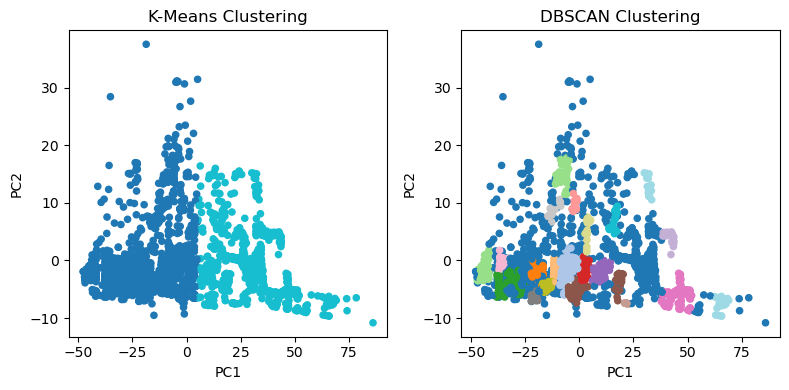

In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2) # Reduce data to 2D
X_pca = pca.fit_transform(X_encoded)

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_encoded)

dbscan = DBSCAN(eps=2.5, min_samples=10) #Taking the best parameters
dbscan_labels = dbscan.fit_predict(X_encoded)

fig, axes = plt.subplots(1, 2, figsize=(8,4))

#Ploting KMeans
axes[0].scatter(X_pca[:,0], X_pca[:,1],c=kmeans_labels,cmap="tab10",s=20)  
axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

#plotting DBScan
axes[1].scatter(X_pca[:,0], X_pca[:,1],c=dbscan_labels,cmap="tab20",s=20)
axes[1].set_title("DBSCAN Clustering")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

### Result

The visual comparison shows the clustering results of K-Means and DBSCAN using two principal components (PC1 and PC2).

K-Means grouped the dataset into **2 clusters**, and every observation was assigned to one of these clusters.

DBSCAN identified **24 clusters** and was also able to identify noise points. The clusters produced by DBSCAN are smaller and more irregular because the algorithm groups observations based on the density of nearby data points.

The visualisation also supports the Silhouette Score results. K-Means produced a higher Silhouette Score (**0.5681**) compared with DBSCAN (**-0.0107**), indicating that K-Means produced better separated clusters for this dataset.

## Part 6: Principal Component Analysis (PCA) of Gene Expression Data

### Discussion

The gene expression dataset was loaded and Principal Component Analysis (PCA) was applied to reduce the number of features.

The dataset contains a large number of gene features. PCA reduces the dimensionality of the dataset while keeping most of the important information.

The data was reduced to **three principal components** so that it can be visualised in a 3D plot. This makes it easy to observe any group or separation between the samples.

Original: (801, 20531)
PCA: (801, 3)


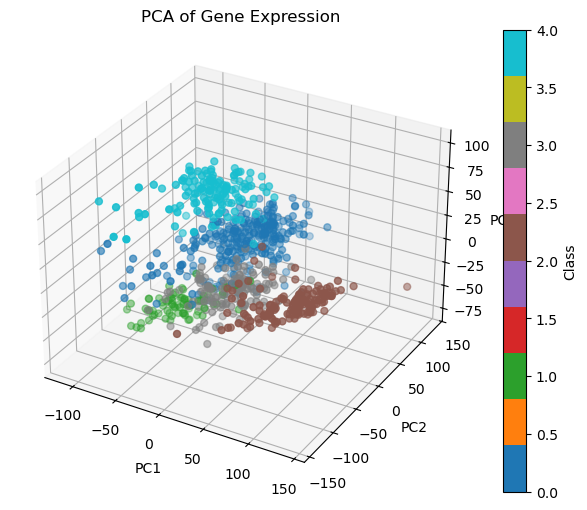

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

data = pd.read_csv("data.csv")
labels = pd.read_csv("labels.csv")

X = data.iloc[:,1:]
y = labels["Class"]

scaler= StandardScaler()
X_norm = scaler.fit_transform(X)

pca= PCA(n_components=3) #PCA
X_pca= pca.fit_transform(X_norm)

print("Original:",X.shape)
print("PCA:",X_pca.shape)

fig =plt.figure(figsize=(8,6)) # 3D Visualisation
ax =fig.add_subplot(111,projection='3d')
scatter = ax.scatter(X_pca[:,0], X_pca[:,1],X_pca[:,2], c=y.astype("category").cat.codes,cmap="tab10",s=25)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA of Gene Expression")
plt.colorbar(scatter, label="Class")
plt.show()

## Result

The gene expression dataset was successfully reduced from **20,531 features** to **3 principal components** using PCA.

The 3D PCA plot shows that some samples form visible groups, while some samples overlap with each other. This indicates that the first three principal components capture important patterns in the dataset, but they do not completely separate all the samples.

Overall, PCA reduced the dimensionality of the dataset and make it easier to see the data while preserving the main variation.

### Key Observation

The PCA technique successfully reduced the gene expression dataset from **20,531 features to 3 principal components**.

The 3D visualisation shows that some sample groups form visible patterns and partial separation based on their class labels. However, several groups still overlap, which indicates that the first three principal components do not completely separate all samples.

Overall, PCA makes the high-dimensional dataset easier to visualise and analyse while retaining important patterns and variation from the original data.

## Part 7: Understanding Variance Explained by PCA

### Discussion

After applying PCA, the amount of information by each principal component was measured using the explained variance ratio.

The explained variance ratio shows how much of the total variance in the original dataset is captured by each principal component. The cumulative explained variance is the total variance when multiple principal components are combined.

The explained variance of the first three principal components was calculated and displayed using a bar chart and a cumulative variance plot.

PC1 Explained Variance:0.1054
PC2 Explained Variance:0.0875
PC3 Explained Variance:0.0781

Cumulative Variance Explained by First Three Components: 0.271


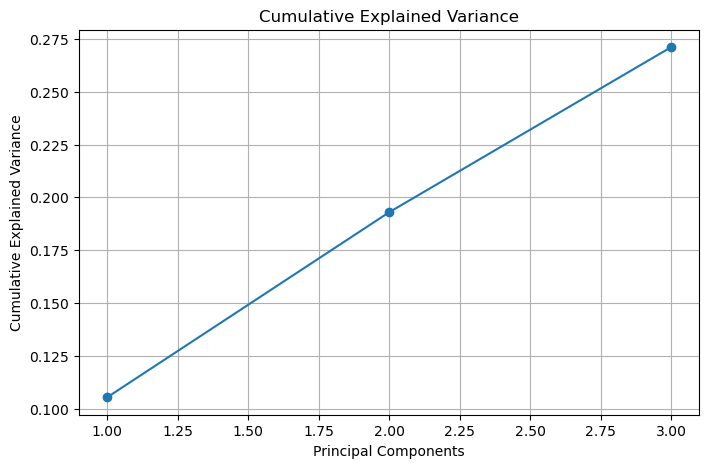

In [24]:
import numpy as np
import matplotlib.pyplot as plt

explained_variance=pca.explained_variance_ratio_  #Explained variance
cumulative_variance= np.cumsum(explained_variance) #Cumulative explained variance

for i in range(3):
    print(f"PC{i+1} Explained Variance:{explained_variance[i]:.4f}")

print("\nCumulative Variance Explained by First Three Components:",round(cumulative_variance[-1],4))
#Cumulative Variance
plt.figure(figsize=(8,5))
plt.plot(range(1,4), cumulative_variance, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

## Result

The explained variance ratio for the first three principal components:

- PC1 Explained Variance = **0.1054**
- PC2 Explained Variance = **0.0875**
- PC3 Explained Variance = **0.0781**

The cumulative variance explained by the first three principal components is **0.2710 (27.10%)**.

The explained variance shows how much information is made by each principal component. In this the first principal component explains the largest amount of variance, while the second and third components explain smaller amounts.

The cumulative explained variance of **27.10%** indicates that the first three principal components are only part of the information in the original dataset. So 3 principal components are useful for visualising the data, but they do not fully represent all the information contained in the original gene expression dataset.

### Key Observation

The first three principal components explain **27.10% of the total variance** in the gene expression dataset.

- **PC1** explains **10.54%** of the variance.
- **PC2** explains **8.75%** of the variance.
- **PC3** explains **7.81%** of the variance.

PC1 captures the largest amount of information, followed by PC2 and PC3. However, since the first three components explain only **27.10%** of the total variance, reducing the dataset to three components results in some loss of information.

Overall, the first three principal components are useful for visualisation and identifying general patterns, but additional components may be required to retain more of the original dataset's information.

## Part 8: Evaluating PCA for Clustering

### Discussion

KMeans clustering was applied to both the original gene expression dataset and the PCA-transformed dataset.

The clustering results were evaluated using the provided class labels. The Adjusted Rand Index (ARI) was to compare the clustering performance. A higher ARI value indicates better agreement between the predicted clusters and the actual class labels.

The results from the original dataset and the PCA dataset were compared to determine whether PCA improved or reduced the clustering performance.

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

k =len(labels["Class"].unique())

# Labels into numeric values
true_labels =labels["Class"].astype("category").cat.codes

# K-Means on Original Dataset
kmeans_original=KMeans(n_clusters=k, random_state=42)
original_clusters= kmeans_original.fit_predict(X_norm)
ari_original =adjusted_rand_score(true_labels, original_clusters)

# K-Means on PCA Dataset
kmeans_pca=KMeans(n_clusters=k, random_state=42)
pca_clusters =kmeans_pca.fit_predict(X_pca)
ari_pca =adjusted_rand_score(true_labels, pca_clusters)

print("Adjusted Rand Index (Original Data):", round(ari_original,4))
print("Adjusted Rand Index (PCA Data):", round(ari_pca,4))

Adjusted Rand Index (Original Data): 0.7972
Adjusted Rand Index (PCA Data): 0.606


## Result

The performance was evaluated using ARI

- ARI(Original Dataset) = **0.7972**
- ARI(PCA Dataset) =**0.6060**

The original gene expression dataset achieved a higher ARI value than the PCA-transformed dataset. This indicates that K-Means performed better on the original data.

The PCA dataset produced a lower ARI because only the first three principal components were used. These three components explained **27.10%** of the total variance, so some information from the original dataset was lost during dimensionality reduction.

PCA reduced the number of features and the dataset easier to visualise.But in this dataset the reduction in dimensionality also reduced the clustering performance.

Therefore, PCA is useful for data visualisation and reducing the size of the dataset, but it is **not recommended as a preprocessing step for clustering this gene expression dataset** because the original dataset produced better clustering results.